# Figures 10–12: the Weddell Sea abyssal pathway

We map bottom SF$_6$ and $\sigma_2$ in the final model year with the sampled transect (Figure 10), show $\sigma_2$ and SF$_6$ sections along the transect with time series at a slope and a deep location (Figure 11), and compare Weddell Sea DSW SWMT, its minimum formation density, and a linear decomposition of the slope-deep density difference (Figure 12). The transect and bottom fields come from `06_prepare_weddell_transect`; the spatial SWMT from `02_prepare_spatial_swmt`.

In [1]:
import string
import sys

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
import gsw
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.colors import BoundaryNorm

sys.path.insert(0, "../src")
from paths import outputdir, plotsdir
from wmt import get_SWMT, select_from_location
from plotting import to_tg, expt_labels, set_style, plot_row, set_uniform_tickscale_y

set_style(dpi=150)


year = 2100  # label for the final model year (2099), repeated at 2100
sf6_scale = 1e12 / 1035 * 1e3  # mol m-3 -> fmol kg-1
slope_loc = (175, -1000)  # (along-section distance [km], depth [m])
deep_loc = (500, -2500)

In [2]:
from dask.distributed import Client

client = Client()  # local workers on this node
client

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32973 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/32973/status,
Dashboard: /proxy/32973/status,Workers: 1
Total threads: 1,Total memory: 160.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33849,Workers: 0
Dashboard: /proxy/32973/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35725,Total threads: 1
Dashboard: /proxy/43441/status,Memory: 160.00 GiB
Nanny: tcp://127.0.0.1:34657,


In [3]:
section = xr.open_dataset(outputdir("Weddell_transect_tracers.zarr"), engine="zarr")
ds_sfc = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"), engine="zarr", chunks={})

s_tie = section["tie_length"].values
lon_tie = section["tie_lon"].values
lat_tie = section["tie_lat"].values

## Transect time series

We put the transect on every year 1850–2099 and repeat 2099 as 2100 so the sections and time series end at 2100.

In [4]:
transect = section[["thetao", "so", "sigma2_offline", "sf6"]].interp(
    year=np.arange(1850, 2100), method="nearest", kwargs={"fill_value": np.nan},
)
transect = xr.concat([transect, transect.sel(year=2099).assign_coords(year=2100)], dim="year")
transect = transect.sel(depth=slice(-5000, None)).compute()

slope = transect.interp(transect_length=slope_loc[0], depth=slope_loc[1], method="nearest", kwargs={"fill_value": np.nan})
deep = transect.interp(transect_length=deep_loc[0], depth=deep_loc[1], method="nearest", kwargs={"fill_value": np.nan})

## Slope-deep density difference

We split $\Delta\sigma_2 = \sigma_2^{\mathrm{deep}} - \sigma_2^{\mathrm{slope}}$ into temperature and salinity contributions using $\rho$, $\alpha$, and $\beta$ at the mean of the two water masses, referenced to 2000 dbar.

In [5]:
p_ref = 2000.0  # sigma2 reference pressure [dbar]

sa_slope, ct_slope = slope["so"].astype("float64"), slope["thetao"]
sa_deep, ct_deep = deep["so"], deep["thetao"]

rho_mid, alpha_mid, beta_mid = xr.apply_ufunc(
    gsw.rho_alpha_beta, (sa_deep + sa_slope) / 2, (ct_deep + ct_slope) / 2, p_ref,
    output_core_dims=[[], [], []],
)

density_diff = (deep["sigma2_offline"] - slope["sigma2_offline"]).to_dataset(name="actual_sigma2_diff")
density_diff["T_contribution"] = -rho_mid * alpha_mid * (ct_deep - ct_slope)
density_diff["S_contribution"] = rho_mid * beta_mid * (sa_deep - sa_slope)

## Weddell Sea DSW SWMT

We sum SWMT over the Weddell Sea sector of the shelf and take its value at the density of maximum SWMT each year, which we use as the minimum formation density of Weddell Sea DSW.

In [6]:
weddell_swmt = get_SWMT(ds_sfc)[["SWMT", "SWMT_heat", "SWMT_salt"]]
weddell_swmt = weddell_swmt.isel(xh=slice(157, 190)).sum(["xh", "yh"]).compute()

swmt = weddell_swmt["SWMT"].fillna(0.0)
dsw_density = swmt["sigma2_l"][swmt.argmax("sigma2_l")].rename("max_surface_boundary_flux_density")
max_swmt = to_tg * select_from_location(weddell_swmt, dsw_density, dim="sigma2_l")

/user/anthony.meza/CM4XAbyssalSWMT/notebooks/../src/wmt.py:127: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  results.append(xr.concat(exp_data, dim="year"))
/user/anthony.meza/CM4XAbyssalSWMT/notebooks/../src/wmt.py:127: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  results.append(xr.concat(exp_data, dim="year")

## Figure 10

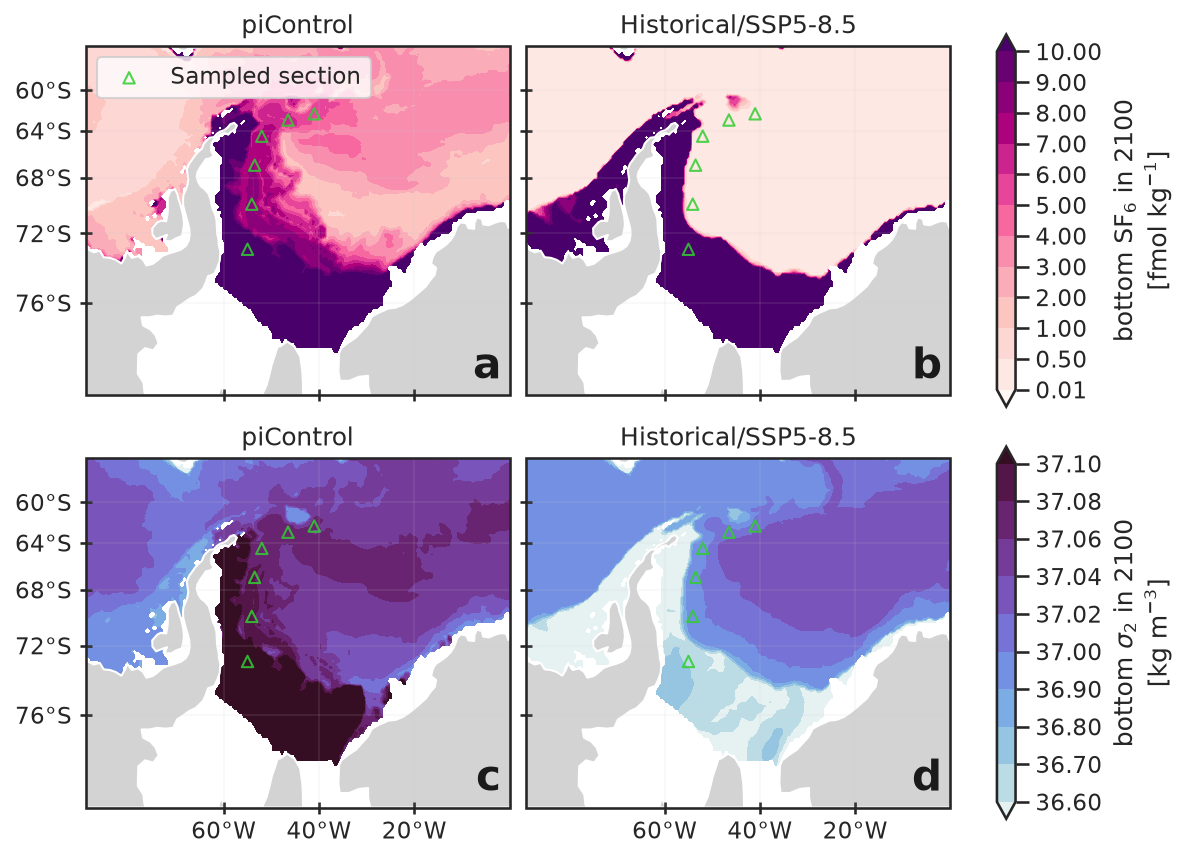

In [7]:
map_extent = (-89, 0, -80, -55)
expts = ["control", "forced"]

data_crs = ccrs.PlateCarree()
map_crs = ccrs.Mercator(min_latitude=map_extent[2], max_latitude=map_extent[3], latitude_true_scale=-70)
land = cfeature.NaturalEarthFeature("physical", "land", "110m", facecolor="lightgrey")

sf6_bounds = np.r_[0.01, 0.5, np.arange(1.0, 11.0, 1.0)]
cmap_sf6 = plt.get_cmap("RdPu", len(sf6_bounds) + 1)
norm_sf6 = BoundaryNorm(sf6_bounds, ncolors=cmap_sf6.N, extend="both")

sigma2_bounds = np.r_[[36.6, 36.7, 36.8, 36.9], np.arange(37.0, 37.1, 0.02)]
cmap_sigma = plt.get_cmap(cmo.dense, len(sigma2_bounds) + 1)
norm_sigma = BoundaryNorm(sigma2_bounds, ncolors=cmap_sigma.N, extend="both")

map_specs = [
    {"data": sf6_scale * section["bottom_sf6"], "bounds": sf6_bounds, "cmap": cmap_sf6, "norm": norm_sf6,
     "cbar_label": rf"bottom SF$_6$ in {year}" + "\n" + r"[fmol kg$^{-1}$]"},
    {"data": section["bottom_sigma2"], "bounds": sigma2_bounds, "cmap": cmap_sigma, "norm": norm_sigma,
     "cbar_label": rf"bottom $\sigma_2$ in {year}" + "\n" + r"[kg m$^{-3}$]"},
]

fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(nrows=2, ncols=2, wspace=0.04, hspace=0.04)
axes = np.array([[fig.add_subplot(gs[row, col], projection=map_crs) for col in range(2)] for row in range(2)])

xticks = np.arange(-60, -19, 20)
yticks = np.arange(-76, -59, 4)

for row, spec in enumerate(map_specs):
    for col, expt in enumerate(expts):
        ax = axes[row, col]
        da = spec["data"].sel(expt=expt)
        mesh = ax.contourf(da.map_lon, da.map_lat, da, levels=spec["bounds"], transform=data_crs,
                           cmap=spec["cmap"], norm=spec["norm"], extend="both", zorder=0)
        ax.set_extent(map_extent, crs=data_crs)
        ax.add_feature(land, zorder=0)
        ax.scatter(lon_tie, lat_tie, transform=data_crs, s=30, edgecolor="limegreen", marker="^",
                   facecolor="None", alpha=0.85, zorder=10,
                   label="Sampled section" if (row, col) == (0, 0) else None)

        ax.set_title(expt_labels[expt])
        ax.text(0.98, 0.02, string.ascii_lowercase[2 * row + col], transform=ax.transAxes, ha="right", va="bottom",
                fontsize=20, fontweight="bold", color="k", zorder=30)
        if (row, col) == (0, 0):
            ax.legend(loc="upper left", frameon=True)

        gl = ax.gridlines(draw_labels=False, crs=data_crs, alpha=0.1)
        gl.xlocator = mticker.FixedLocator(xticks)
        gl.ylocator = mticker.FixedLocator(yticks)
        ax.set_xticks(xticks, crs=data_crs)
        ax.set_yticks(yticks, crs=data_crs)
        ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(direction="inout", labelleft=(col == 0), labelbottom=(row == 1), zorder=100)

    cbar = fig.colorbar(mesh, ax=axes[row, :], orientation="vertical", ticks=spec["bounds"],
                        fraction=0.02, spacing="uniform", extend="both")
    cbar.set_label(spec["cbar_label"])

fig.savefig(plotsdir("fig10_weddell_maps.png"), dpi=350, bbox_inches="tight")

## Figure 11

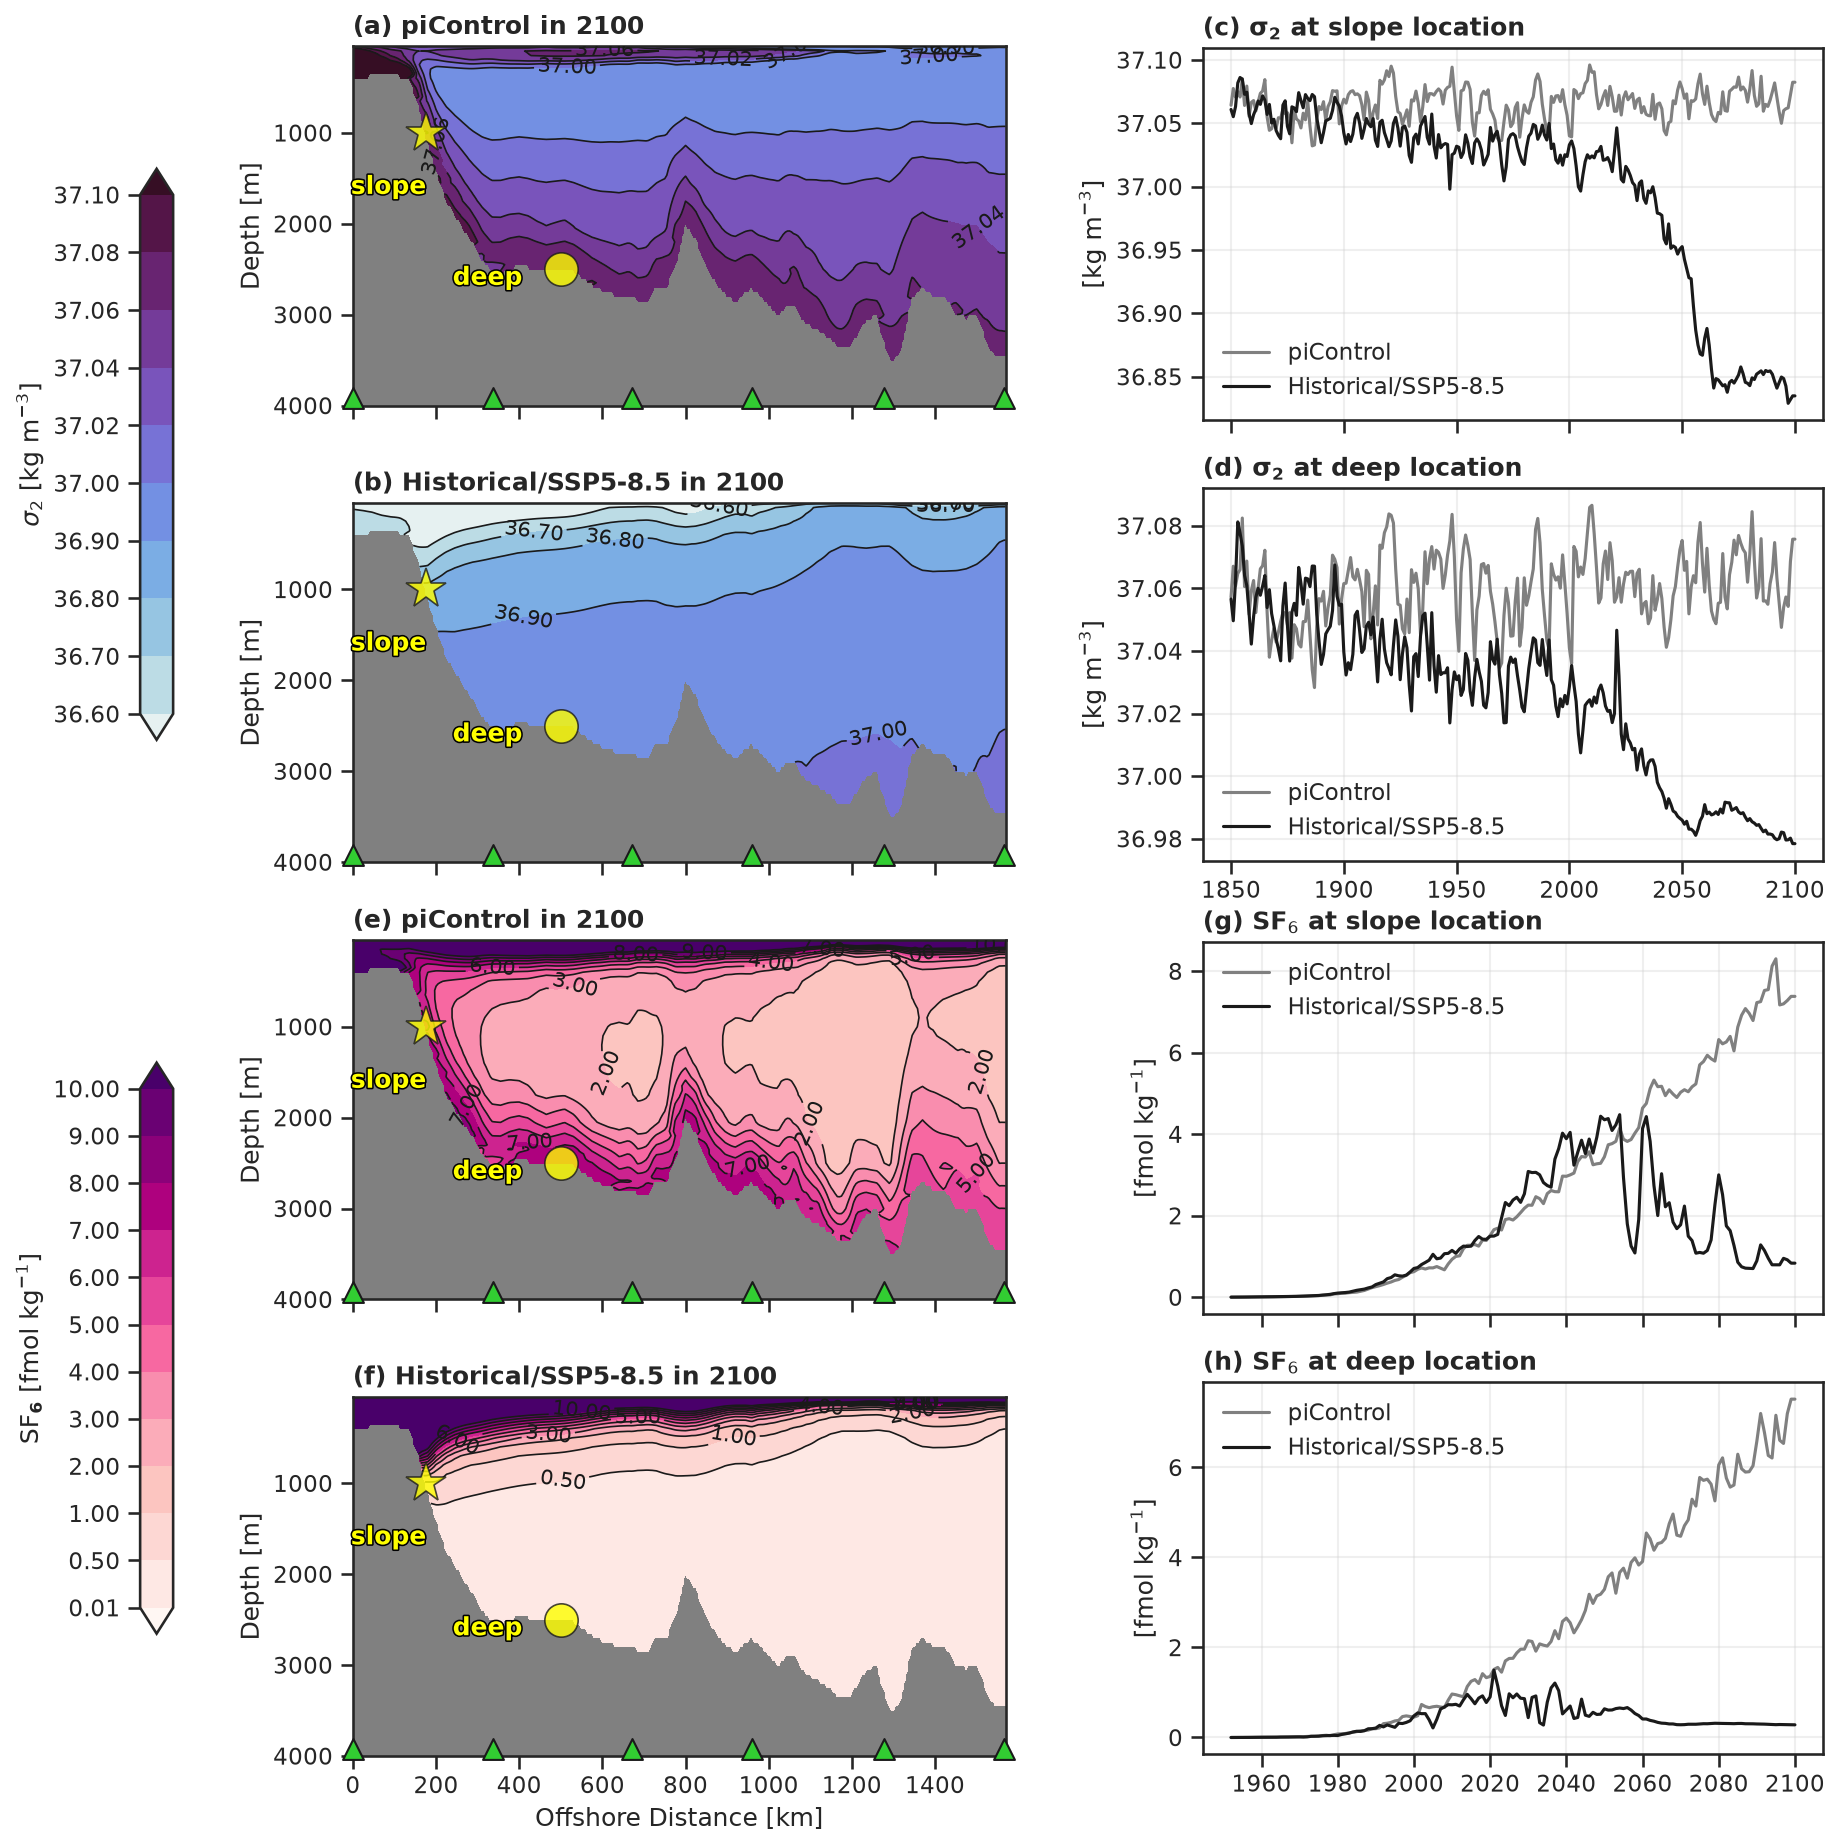

In [8]:
fig = plt.figure(figsize=(11, 13), constrained_layout=False)
gs = fig.add_gridspec(2, 2, width_ratios=(1.1, 1.0), height_ratios=(1.0, 1.0), wspace=0.28, hspace=0.015)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.06, top=0.97)

axs = {}
for row in range(2):
    gs_section = gs[row, 0].subgridspec(2, 1, hspace=0.0)
    gs_timeseries = gs[row, 1].subgridspec(2, 1, hspace=0.0)
    axs[row] = {}
    axs[row]["section_control"] = fig.add_subplot(gs_section[0, 0])
    axs[row]["section_forced"] = fig.add_subplot(gs_section[1, 0], sharex=axs[row]["section_control"])
    axs[row]["surf"] = fig.add_subplot(gs_timeseries[0, 0])
    axs[row]["bot"] = fig.add_subplot(gs_timeseries[1, 0], sharex=axs[row]["surf"])
    for key in ["section_control", "section_forced"]:
        axs[row][key].set_box_aspect(0.55)
    for key in ["surf", "bot"]:
        axs[row][key].set_box_aspect(0.6)

row_kwargs = dict(year=year, s_tie=s_tie, z=slice(-4000, -10), contour_fmt="%.2f",
                  surf_loc=slope_loc, bot_loc=deep_loc, cbar_width=0.02, cbar_pad=0.1)

plot_row(
    fig, axs[0], transect.sigma2_offline, levels=sigma2_bounds, cmap=cmap_sigma,
    units=r"kg m$^{-3}$", cbar_label=r"${\sigma_2}$ [kg m$^{-3}$]",
    section_titles=[rf"(a) piControl in {year}", rf"(b) Historical/SSP5-8.5 in {year}"],
    timeseries_titles=[r"(c) $\mathbf{\sigma_2}$ at slope location", r"(d) $\mathbf{\sigma_2}$ at deep location"],
    hide_section_xlabel=True, **row_kwargs,
)
plot_row(
    fig, axs[1], transect.sf6, levels=sf6_bounds, cmap=cmap_sf6, scale=sf6_scale,
    units=r"fmol kg$^{-1}$", cbar_label=r"SF$\mathbf{_6}$ [fmol kg$^{-1}$]",
    section_titles=[rf"(e) piControl in {year}", rf"(f) Historical/SSP5-8.5 in {year}"],
    timeseries_titles=[r"(g) SF$\mathrm{_6}$ at slope location", r"(h) SF$\mathrm{_6}$ at deep location"],
    hide_section_xlabel=False, **row_kwargs,
)

fig.savefig(plotsdir("fig11_weddell_sections.png"), dpi=350, bbox_inches="tight")

## Figure 12

All time series are 30-year backward rolling means.

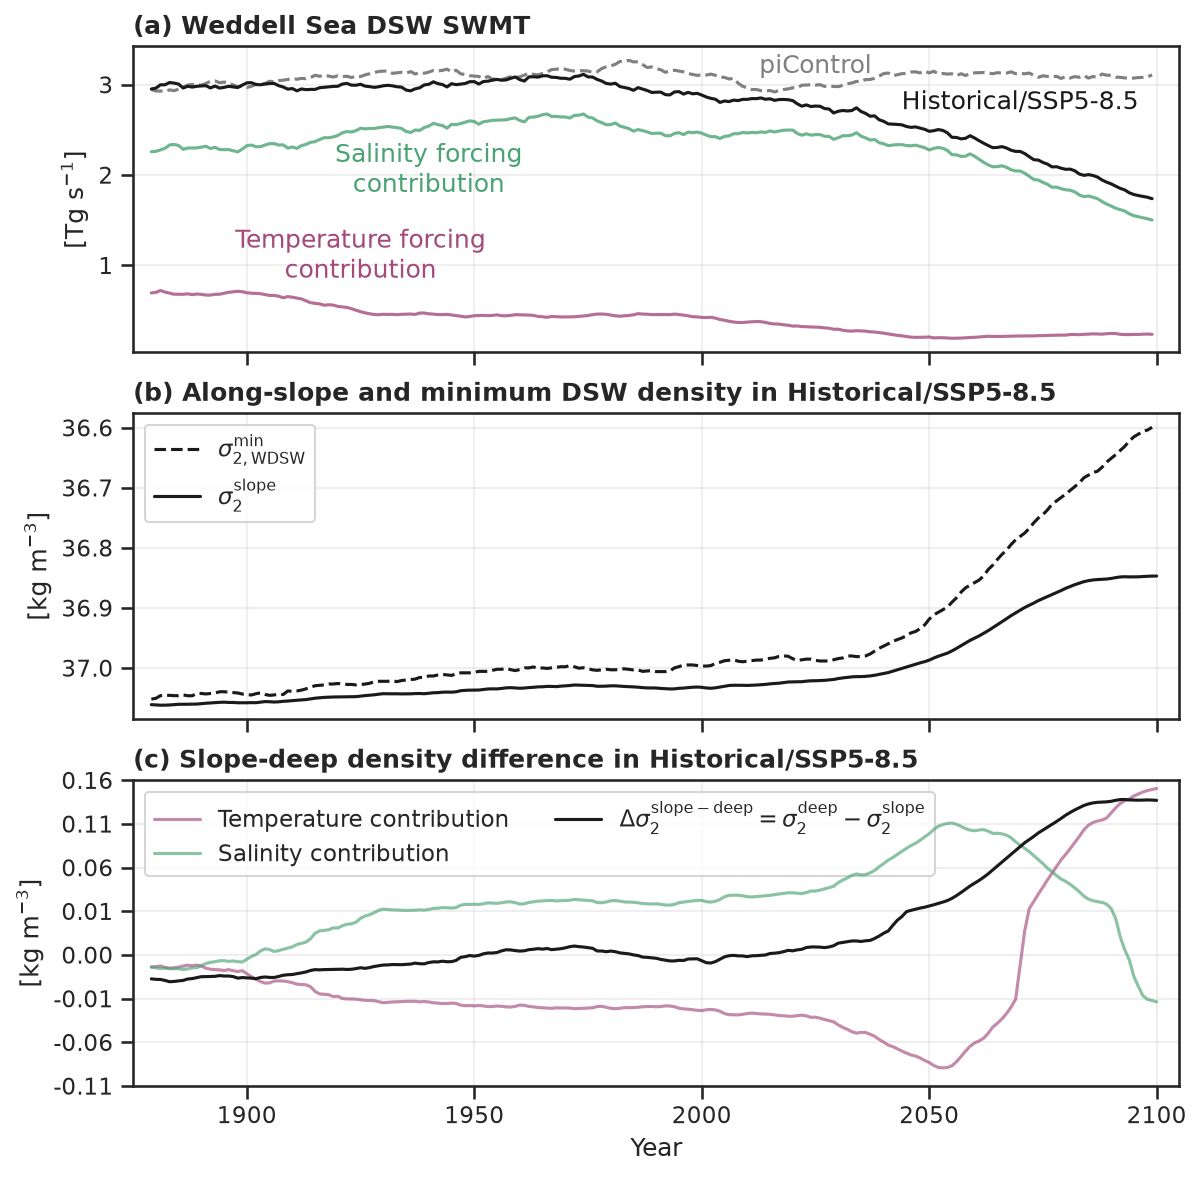

In [9]:
roll = lambda x: x.rolling(year=30, center=False).mean("year")

swmt_colors = {"temperature": "#A34B7B", "salinity": "#4BA373"}
line_colors = {"forced": "k", "control": "grey"}
line_styles = {"forced": "-", "control": "--"}

max_swmt_roll = roll(max_swmt)
dsw_density_roll = roll(dsw_density)
slope_sigma2_roll = roll(slope["sigma2_offline"].rename({"expt": "exp"}))
density_diff_roll = roll(density_diff)

fig, axs = plt.subplots(3, 1, figsize=(9, 9), sharex=True, gridspec_kw={"hspace": 0.2})
ax0, ax1, ax2 = axs

ax0.plot(max_swmt_roll.year, max_swmt_roll["SWMT_heat"].sel(exp="forced"),
         color=swmt_colors["temperature"], alpha=0.8, linewidth=1.5, zorder=10)
ax0.plot(max_swmt_roll.year, max_swmt_roll["SWMT_salt"].sel(exp="forced"),
         color=swmt_colors["salinity"], alpha=0.8, linewidth=1.5, zorder=10)
for exp in ["control", "forced"]:
    ax0.plot(max_swmt_roll.year, max_swmt_roll["SWMT"].sel(exp=exp),
             color=line_colors[exp], linestyle=line_styles[exp], linewidth=1.5)
ax0.text(1925, 1.1, "Temperature forcing\ncontribution", color=swmt_colors["temperature"], ha="center", va="center")
ax0.text(1940, 2.05, "Salinity forcing\ncontribution", color=swmt_colors["salinity"], ha="center", va="center")
ax0.text(2070, 2.8, expt_labels["forced"], color=line_colors["forced"], ha="center", va="center")
ax0.text(2025, 3.2, expt_labels["control"], color=line_colors["control"], ha="center", va="center")
ax0.set_ylabel(r"[Tg s$^{-1}$]")
ax0.set_title(r"(a) Weddell Sea DSW SWMT", loc="left", fontweight="bold")

ax1.plot(dsw_density_roll.year, dsw_density_roll.sel(exp="forced"), color=line_colors["forced"],
         label=r"$\sigma^{\mathrm{min}}_{2, \mathrm{WDSW}}$", linewidth=1.5, linestyle="--")
ax1.plot(slope_sigma2_roll.year, slope_sigma2_roll.sel(exp="forced"), color=line_colors["forced"],
         linestyle="-", linewidth=1.5, label=r"${\sigma^{\mathrm{slope}}_2}$", zorder=10)
ax1.set_ylabel(r"[kg m$^{-3}$]")
ax1.invert_yaxis()
ax1.set_title(r"(b) Along-slope and minimum DSW density in Historical/SSP5-8.5", loc="left", fontweight="bold")
ax1.legend()

ax2.plot(density_diff_roll.year, density_diff_roll["T_contribution"].sel(expt="forced"),
         color=swmt_colors["temperature"], alpha=0.65, linewidth=1.5, label="Temperature contribution", zorder=8)
ax2.plot(density_diff_roll.year, density_diff_roll["S_contribution"].sel(expt="forced"),
         color=swmt_colors["salinity"], alpha=0.65, linewidth=1.5, label="Salinity contribution", zorder=8)
ax2.plot(density_diff_roll.year, density_diff_roll["actual_sigma2_diff"].sel(expt="forced"),
         color=line_colors["forced"], linestyle=line_styles["forced"], linewidth=1.5, zorder=10,
         label=r"$\Delta \sigma^{\mathrm{slope-deep}}_2 = {\sigma^{\mathrm{deep}}_2}- {\sigma^{\mathrm{slope}}_2}$")
ax2.set_ylabel(r"[kg m$^{-3}$]")
set_uniform_tickscale_y(ax2, [-0.11, -0.06, -0.01, 0.0, 0.01, 0.06, 0.11, 0.16])  # finer steps near zero
ax2.set_title(r"(c) Slope-deep density difference in Historical/SSP5-8.5", loc="left", fontweight="bold")
ax2.legend(ncols=2)

for ax in axs:
    ax.grid(alpha=0.3)
    ax.set_xlabel("")
    ax.set_xlim(1875, 2105)
ax2.set_xlabel("Year")

fig.savefig(plotsdir("fig12_weddell_time_series.png"), dpi=350, bbox_inches="tight")